# A5 - ANN-NARX on Ball-and-Beam: sweep over ny, nu and network architectures

Notebook version of `ann_narx_ball_and_beam.py`.

Approach 1 of the A5 activity ("apply each approach to your case study").

Ported from the course example
    https://helonayala.github.io/sysid/ANN_narx.html
and applied to the REAL ball-and-beam data with the same input values used in
A2 / A3 / A4:

    experiment='multisine_05', resample_factor=50, y_dot_method='savgol',
    50/50 train/test split.

As in A4, a min-max normalisation to [0, 1] (fit on the TRAIN half only) is
added, because the ball-and-beam signals are in arbitrary physical units while
the original Narendra benchmark is already in range.

What this script does that A4 does not
--------------------------------------
It SWEEPS the NARX hyper-parameters requested by the activity:
  * different memory orders  (ny, nu)
  * different network architectures  (number of hidden layers x neurons)
and reports one-step-ahead (OSA) and free-run (FR) R^2 on the test half for
every combination, then plots the best free-run model.

Requires:  torch, bab_datasets, scikit-learn
Run with:  python ann_narx_ball_and_beam.py

## Imports and setup

In [ ]:
import os
import itertools

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

HERE = os.path.abspath(os.path.dirname("__file__") or os.getcwd())

try:
    import bab_datasets as nod
except ImportError as exc:  # pragma: no cover
    raise SystemExit(
        "The 'bab_datasets' package is required.\n"
        "    pip install --upgrade git+https://github.com/helonayala/bab_datasets.git"
    ) from exc

## Reproducibility

In [ ]:
RSEED = 42
np.random.seed(RSEED)
torch.manual_seed(RSEED)
np.set_printoptions(precision=3)

## Configuration (same ball-and-beam inputs as A2/A3/A4)

In [ ]:
EXPERIMENT = "multisine_05"
RESAMPLE_FACTOR = 50
Y_DOT_METHOD = "savgol"
TRAIN_FRACTION = 0.5

EPOCHS = 200
BATCH_SIZE = 32
LR = 1e-3

### the sweep grids requested by the activity

In [ ]:
NY_NU_GRID = [(1, 1), (2, 2), (3, 2), (3, 3)]          # memory orders
ARCH_GRID = [(1, 32), (2, 32), (3, 80), (3, 64)]       # (hidden layers, neurons)

## NARX helpers (verbatim from ANN_narx.html)

In [ ]:
def matReg(y, u, ny, nu):
    p = np.max((ny, nu)) + 1
    (N, ) = y.shape
    (Nu, ) = u.shape
    if N != Nu:
        print('Dimensions of u and y vector are not consistent')
        return (-1, -1)
    target = y[p - 1:N]
    Phi = np.zeros((N - p + 1, ny + nu))
    for i in range(ny):
        Phi[:, i] = y[p - i - 2: N - i - 1]
    for i in range(nu):
        Phi[:, i + ny] = u[p - i - 2: N - i - 1]
    return (target, Phi)

In [ ]:
def freeRun(model, y, u, ny, nu):
    p = max(ny, nu) + 1
    (N, ) = y.shape
    yhat = np.zeros(N)
    yhat[:p - 1] = y[:p - 1]
    for k in range(p, N + 1):
        auxY = np.concatenate((yhat[(k - p):(k - 1)], (0, )), axis=0)
        auxU = np.concatenate((u[(k - p):(k - 1)], (0, )), axis=0)
        _, fr_input = matReg(auxY, auxU, ny, nu)
        yhat[k - 1] = model.predict(torch.tensor(fr_input, dtype=torch.float32))
    return yhat[-(N - p + 1):]

## Normalisation to [0, 1]

In [ ]:
def fit_minmax(x):
    return float(np.min(x)), float(np.max(x))

In [ ]:
def normalize(x, lo, hi):
    return (x - lo) / (hi - lo)

In [ ]:
def denormalize(xn, lo, hi):
    return xn * (hi - lo) + lo

## Data loading (bab_datasets, identical call to A2/A3/A4)

In [ ]:
def load_data():
    data = nod.load_experiment(
        EXPERIMENT, preprocess=True, plot=False, end_idx=None,
        resample_factor=RESAMPLE_FACTOR, zoom_last_n=10000,
        y_dot_method=Y_DOT_METHOD,
    )
    u = np.asarray(data.u, dtype=float).ravel()
    y = np.asarray(data.y, dtype=float).ravel()
    ts = float(data.sampling_time)
    return u, y, ts

## Configurable MLP (SELU hidden layers, Kaiming init) - reference architecture

In [ ]:
class MLP(nn.Module):
    def __init__(self, ninp, n_layers, nneu, nout=1):
        super().__init__()
        sizes = [ninp] + [nneu] * n_layers
        self.hidden = nn.ModuleList(
            [nn.Linear(sizes[i], sizes[i + 1]) for i in range(n_layers)])
        self.output = nn.Linear(nneu, nout)
        for h in self.hidden:
            nn.init.kaiming_normal_(h.weight, nonlinearity='selu')
        nn.init.kaiming_normal_(self.output.weight, nonlinearity='linear')

    def forward(self, x):
        for h in self.hidden:
            x = F.selu(h(x))
        return self.output(x)

    def predict(self, x):
        with torch.no_grad():
            return self.forward(x)

In [ ]:
def train_one(Phie_t, Ye_t, ninp, n_layers, nneu, epochs=EPOCHS):
    """Train a single ANN-NARX model and return it."""
    model = MLP(ninp, n_layers, nneu, nout=1)
    optimizer = optim.NAdam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    loader = DataLoader(TensorDataset(Phie_t, Ye_t),
                        batch_size=BATCH_SIZE, shuffle=True)
    for _ in range(epochs):
        model.train()
        for inputs, targets in loader:
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

## Main - sweep ny, nu and architectures

In [ ]:
u, y, ts = load_data()
n = u.size
split = int(round(TRAIN_FRACTION * n))
ue, ye = u[:split], y[:split]
ut, yt = u[split:], y[split:]

# min-max [0,1] normalisation, fit on train half only
u_lo, u_hi = fit_minmax(ue)
y_lo, y_hi = fit_minmax(ye)
ue_n, ye_n = normalize(ue, u_lo, u_hi), normalize(ye, y_lo, y_hi)
ut_n, yt_n = normalize(ut, u_lo, u_hi), normalize(yt, y_lo, y_hi)

print("=" * 78)
print(f"A5 ANN-NARX sweep - Ball-and-Beam ('{EXPERIMENT}', Ts={ts:.3f}s)")
print(f"train={ue.size}  test={ut.size}   (R2 reported on the TEST half)")
print("=" * 78)
print(f"{'ny':>3}{'nu':>3}{'layers':>8}{'neurons':>9}"
      f"{'OSA R2':>10}{'FR R2':>10}")
print("-" * 78)

results = []
for (ny, nu), (n_layers, nneu) in itertools.product(NY_NU_GRID, ARCH_GRID):
    torch.manual_seed(RSEED)          # same init across configs -> fair
    (Ye, Phie) = matReg(ye_n, ue_n, ny, nu)
    (Yt, Phit) = matReg(yt_n, ut_n, ny, nu)
    Phie_t = torch.tensor(Phie, dtype=torch.float32)
    Ye_t = torch.tensor(Ye, dtype=torch.float32)
    Phit_t = torch.tensor(Phit, dtype=torch.float32)

    model = train_one(Phie_t, Ye_t, ny + nu, n_layers, nneu)

    osa = model.predict(Phit_t).squeeze().numpy()
    r2_osa = r2_score(Yt, osa)
    fr = freeRun(model, yt_n, ut_n, ny, nu)
    r2_fr = r2_score(Yt, fr)

    results.append(dict(ny=ny, nu=nu, n_layers=n_layers, nneu=nneu,
                        r2_osa=r2_osa, r2_fr=r2_fr))
    print(f"{ny:>3}{nu:>3}{n_layers:>8}{nneu:>9}{r2_osa:>10.4f}{r2_fr:>10.4f}")

### best model by free-run R2

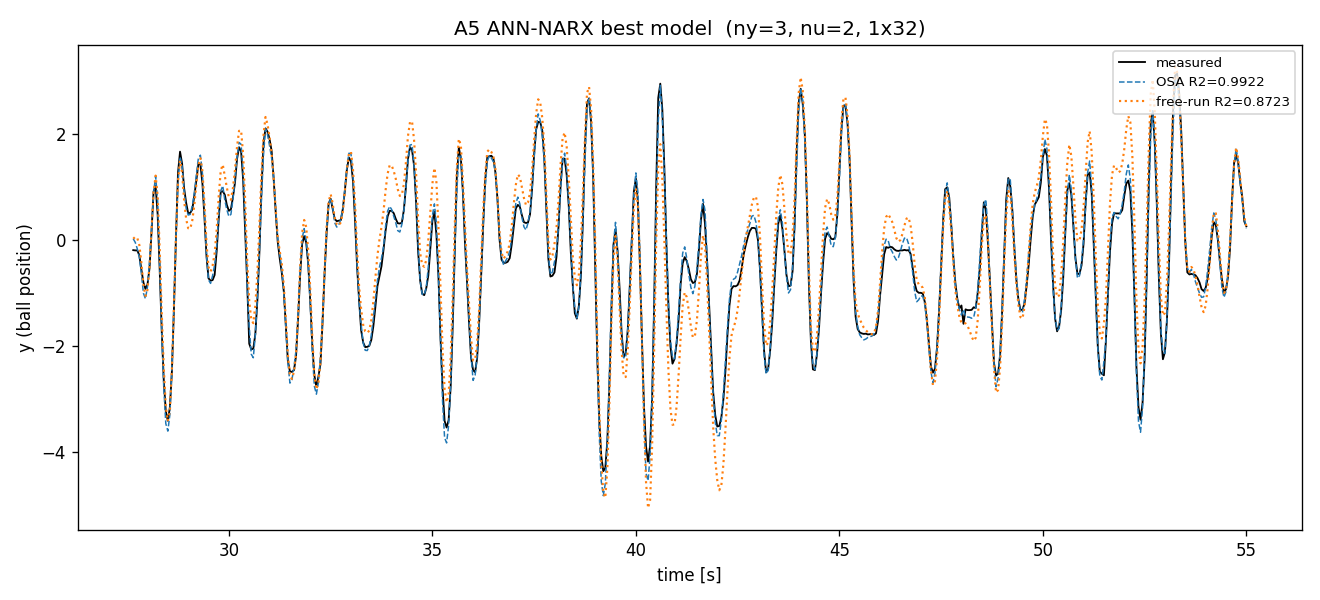

In [1]:
best = max(results, key=lambda r: r["r2_fr"])
print("-" * 78)
print(f"BEST (free-run): ny={best['ny']} nu={best['nu']} "
      f"layers={best['n_layers']} neurons={best['nneu']}  "
      f"OSA R2={best['r2_osa']:.4f}  FR R2={best['r2_fr']:.4f}")

# retrain best for the plot (deterministic)
ny, nu = best["ny"], best["nu"]
torch.manual_seed(RSEED)
(Ye, Phie) = matReg(ye_n, ue_n, ny, nu)
(Yt, Phit) = matReg(yt_n, ut_n, ny, nu)
model = train_one(torch.tensor(Phie, dtype=torch.float32),
                  torch.tensor(Ye, dtype=torch.float32),
                  ny + nu, best["n_layers"], best["nneu"])
osa = model.predict(torch.tensor(Phit, dtype=torch.float32)).squeeze().numpy()
fr = freeRun(model, yt_n, ut_n, ny, nu)

p = max(ny, nu) + 1
t_test = (split + (p - 1) + np.arange(Yt.size)) * ts
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(t_test, denormalize(Yt, y_lo, y_hi), "k", lw=1.1, label="measured")
ax.plot(t_test, denormalize(osa, y_lo, y_hi), "--", lw=0.9,
        label=f"OSA R2={best['r2_osa']:.4f}")
ax.plot(t_test, denormalize(fr, y_lo, y_hi), ":", lw=1.3,
        label=f"free-run R2={best['r2_fr']:.4f}")
ax.set_title(f"A5 ANN-NARX best model  "
             f"(ny={ny}, nu={nu}, {best['n_layers']}x{best['nneu']})")
ax.set_xlabel("time [s]")
ax.set_ylabel("y (ball position)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(HERE, "a5_ann_narx_best.png"), dpi=120)
print("\nSaved figure: a5_ann_narx_best.png")